Important libraries


In [1]:
import os
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

In [2]:
train_dir = "../datasets/facial/train"
test_dir = "../datasets/facial/test"

print("Training Path:", train_dir)
print("Testing Path :", test_dir)

Training Path: ../datasets/facial/train
Testing Path : ../datasets/facial/test


List emotion calsses

In [3]:
emotion_classes = sorted(os.listdir(train_dir))

print("Emotion Classes:")
print(emotion_classes)

print(f"\nNumber of classes: {len(emotion_classes)}")

Emotion Classes:
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Number of classes: 7


counting images 

In [4]:
train_counts = {}

for emotion in emotion_classes:
    folder = os.path.join(train_dir, emotion)
    train_counts[emotion] = len(os.listdir(folder))

train_counts

{'angry': 3995,
 'disgust': 436,
 'fear': 4097,
 'happy': 7215,
 'neutral': 4965,
 'sad': 4830,
 'surprise': 3171}

In [5]:
pd.DataFrame.from_dict(
    train_counts,
    orient="index",
    columns=["Training Images"]
)

,Training Images
angry,3995
disgust,436
fear,4097
happy,7215
neutral,4965
sad,4830
surprise,3171


Plotting the calss distribution

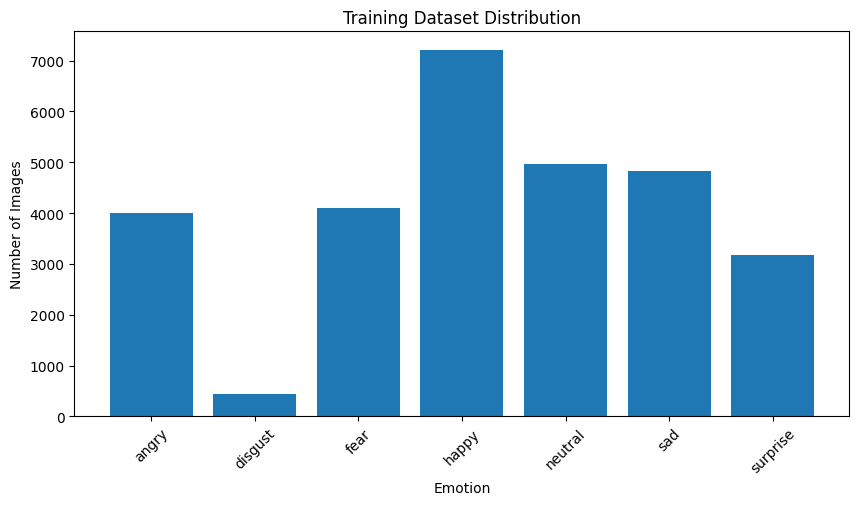

In [6]:
plt.figure(figsize=(10,5))

plt.bar(train_counts.keys(), train_counts.values())

plt.title("Training Dataset Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Images")

plt.xticks(rotation=45)

plt.show()

Displaying the sample images 

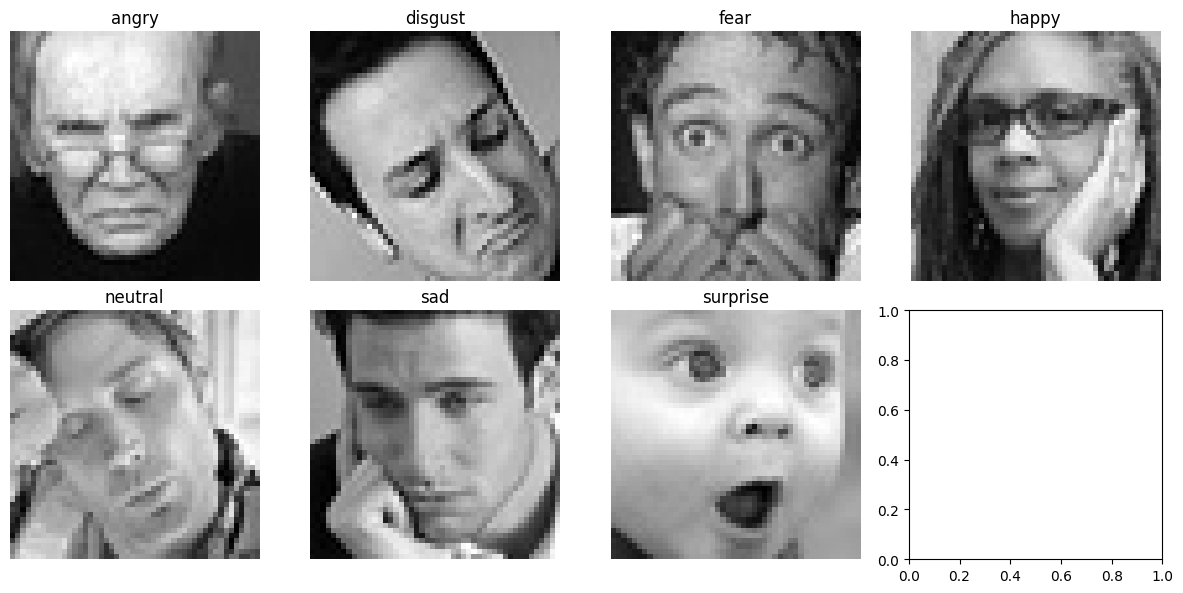

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(12,6))

axes = axes.flatten()

for i, emotion in enumerate(emotion_classes):

    folder = os.path.join(train_dir, emotion)

    image_name = random.choice(os.listdir(folder))

    image_path = os.path.join(folder, image_name)

    img = Image.open(image_path)

    axes[i].imshow(img, cmap="gray")

    axes[i].set_title(emotion)

    axes[i].axis("off")

plt.tight_layout()

plt.show()

The dataset is highly imbalanced.

Happy → 7215

Disgust → 436

That's over a 16× difference.

means if we train naively, the model will likely perform poorly on the disgust class.

We will not oversample or undersample yet. Instead, lets use class weights during training, which is a standard and effective approach for this kind of imbalance.

# Data preprocessing

In [8]:
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [9]:
print(tf.__version__)

2.13.0


In [10]:
IMG_SIZE = 48
BATCH_SIZE = 64
SEED = 42

Data genrator

In [11]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(
    rescale=1.0 / 255
)

Training genrator

In [12]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=SEED
)

Found 22968 images belonging to 7 classes.


Validation generator

In [13]:
validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
    seed=SEED
)

Found 5741 images belonging to 7 classes.


Test Genrator

In [14]:
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 7178 images belonging to 7 classes.


Verify the genrators

In [15]:
images, labels = next(train_generator)

print("Image Batch Shape :", images.shape)
print("Label Batch Shape :", labels.shape)

Image Batch Shape : (64, 48, 48, 1)
Label Batch Shape : (64, 7)


Visualization of the augumented batch

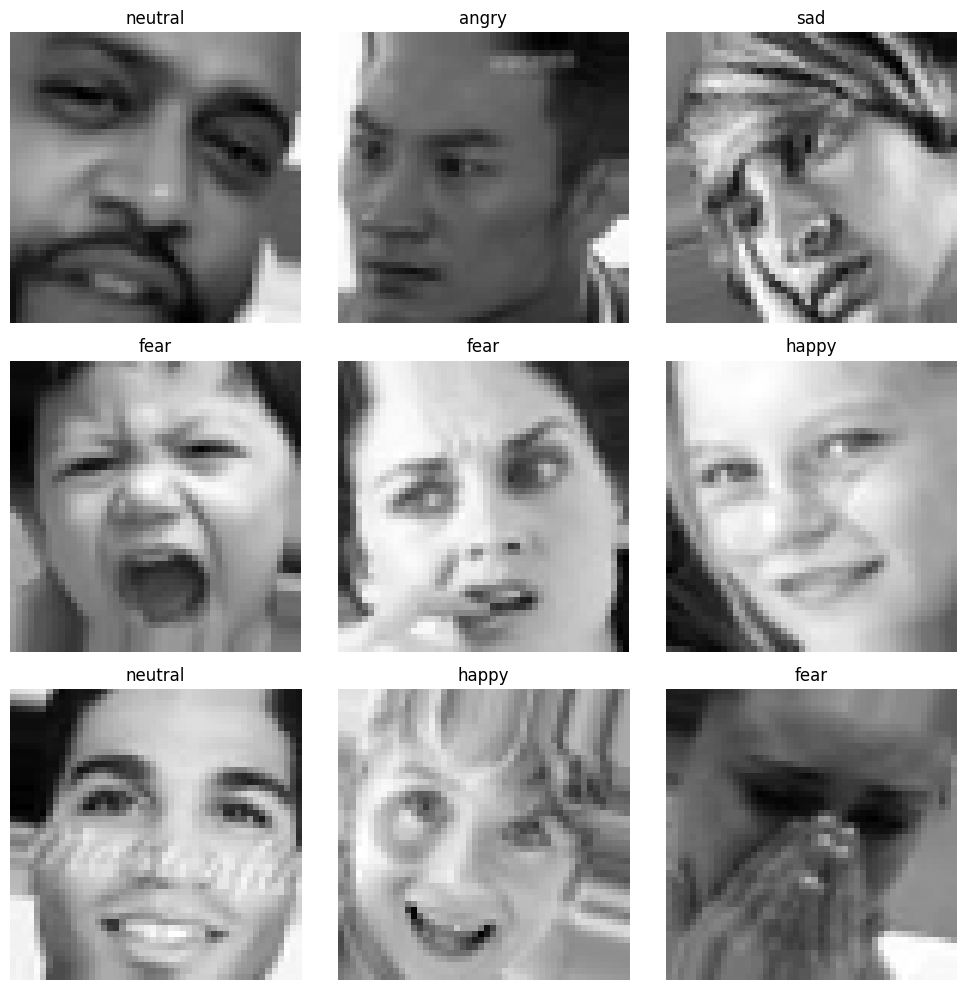

In [16]:
plt.figure(figsize=(10, 10))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(emotion_classes[np.argmax(labels[i])])
    plt.axis("off")

plt.tight_layout()
plt.show()

# CNN Model

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Dropout,
    Flatten,
    Dense,
)
from tensorflow.keras.optimizers import Adam

Build the model

In [18]:
model = Sequential([

    Input(shape=(48, 48, 1)),

    Conv2D(32, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(),
    Dropout(0.25),

    Conv2D(64, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(),
    Dropout(0.25),

    Conv2D(128, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(),
    Dropout(0.30),

    Flatten(),

    Dense(256, activation="relu"),
    Dropout(0.50),

    Dense(7, activation="softmax")
])

In [19]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [20]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 48, 48, 32)        320       
                                                                 
 batch_normalization (Batch  (None, 48, 48, 32)        128       
 Normalization)                                                  
                                                                 
 max_pooling2d (MaxPooling2  (None, 24, 24, 32)        0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 24, 24, 32)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 24, 24, 64)        18496     
                                                                 
 batch_normalization_1 (Bat  (None, 24, 24, 64)        2

Compute the calsss weights

In [21]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: 1.0266404434114071, 1: 9.401555464592715, 2: 1.0009587727708533, 3: 0.5684585684585685, 4: 0.826068191627104, 5: 0.8491570541259982, 6: 1.2933160650937552}


Saving model architecture 

In [22]:
import os

os.makedirs("../reports/results", exist_ok=True)

with open("../reports/results/facial_model_summary.txt", "w") as f:
    model.summary(print_fn=lambda x: f.write(x + "\n"))